### Figure 3 E: Heatmap with significance indication (as asterics)

In [2]:
# Load necessary libraries
library(dplyr) # e.g. for "%>%" functionality 
library(stringr)
library(coin)
library(tidyverse)
library(ggplot2)
library(ggpubr)

Warning message:
"Paket 'ggplot2' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'tibble' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'tidyr' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'readr' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'purrr' wurde unter R Version 4.4.3 erstellt"
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.2.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"Paket 'ggpubr' wurde unter R Version 4.4.3 erstellt"


In [3]:
filepath= "./NotebooksForUpload/disease_specificity_results.csv"
data <- read.csv(filepath,sep=",", header=TRUE, stringsAsFactors=FALSE)
#data[,1]
data <- data[-c(14), ]

In [4]:
# Pathways = Metaproteins
# s1 adjPval --> p-value berechnen für Studie 1 
# s1 logFC --> FC berechnen für Studie 1

sampleSpecificdata <- data.frame( # change S1, S2 to the disease that was used there --> maybe put author in brackets)
  "Pathways" = data[,1],
  "GCA_adjPval" = data[,6],
  "GCA_logFC" = data[,5],
  "CA_adjPval" = data[,11],
  "CA_logFC" = data[,10],
  "IBS_adjPval" = data[,16],
  "IBS_logFC" = data[,15],
  "NASH_adjPval" = data[,21],
  "NASH_logFC" = data[,20],
  "HCC_adjPval" = data[,26],
  "HCC_logFC" = data[,25],
  "Diabetes_adjPval" = data[,31],
  "Diabetes_logFC" = data[,30]
)


#reshape to long format for plotting
plotdata2 <- sampleSpecificdata %>%
  pivot_longer(
    cols = !Pathways,
    names_to = c("sample", ".value"),
    names_sep = "_"
  ) %>% mutate(label = cut(
    adjPval,
    breaks = c(0, 0.001, 0.01, 0.05, 1),
    labels = c("***", "**", "*", " ")
  ))
#cluster to order rows

clustering2 <- sampleSpecificdata %>% select(ends_with("logFC")) %>% dist() %>% hclust(method="median")
plotdata2[["Pathways"]] <- factor(plotdata2[["Pathways"]],levels=paste(data[,1])[clustering2[["order"]]])


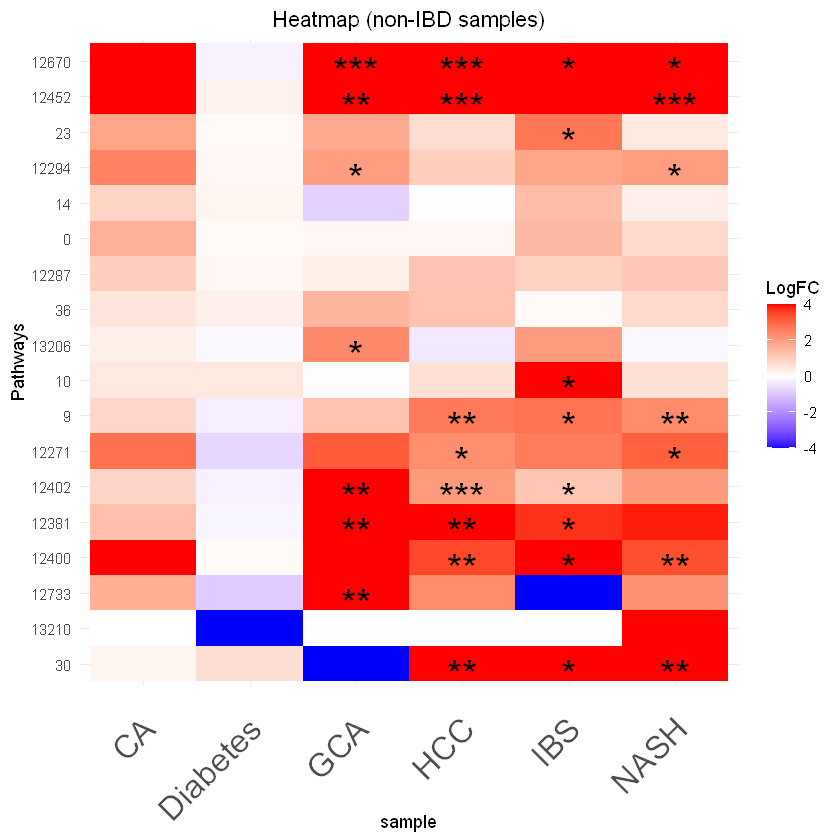

In [5]:
set.seed(1)
plotdata2$logFC <- pmin(pmax(plotdata2$logFC, -4), 4) # values are capped to specific range (workaround as otherwise values out of scale would be colored e.g. grey)


# create plot
heatmap2 <- ggplot(plotdata2,aes(x=sample,y=Pathways,fill=logFC, label=label)) + geom_tile() +
scale_fill_gradientn(
    colors = c("blue", "white", "red"), # needs to be specified (but has no impact) 
    limits = c(-4, 4), # to set a fixed range for comparability if not specified, the minimal and maximal value will decide on range
)+ geom_text(size=8,hjust=0.5, vjust=0.8)  +  theme_minimal() +
  labs(title = "Heatmap (non-IBD samples)", fill = "LogFC") +
  theme(
    plot.title = element_text(hjust = 0.5),axis.text.x = element_text(angle = 45, vjust = 0.8, hjust=1, size =20)
  )

figure <-heatmap2
#figure <- ggarrange(heatmap2,
#                    labels = c("B"),
#                    ncol = 1, nrow = 1)
ggsave("HeatmapsHumanProteins.jpeg", figure, width=4, height=8, dpi=300)
figure